# **Mental Health Prediction Using Various ML/DL Methods**

## **Introduction**

Mental health disorders have become a major global health concern, affecting individuals across different age groups, occupations, and social backgrounds. Mental health challenges continue to affect employee well-being, productivity, and quality of life across industries worldwide. Despite increased awareness, many individuals experiencing mental health difficulties do not seek professional support due to factors such as stigma, lack of workplace support, limited awareness, and accessibility barriers. Understanding the factors that influence mental health support-seeking behavior is essential for designing effective interventions and promoting employee well-being.

With advances in Artificial Intelligence (AI), Machine Learning (ML), and Deep Learning (DL), predictive systems can assist in identifying patterns and factors associated with individuals' likelihood of seeking mental health support. Such systems can provide valuable insights for healthcare professionals, employers, researchers, and policymakers in creating more supportive workplace environments and improving access to mental health resources.

This project focuses on analyzing and predicting employees' likelihood of seeking mental health treatment using survey data obtained from publicly available datasets. The study involves data cleaning, preprocessing, exploratory data analysis, and feature selection techniques to identify demographic, workplace, and psychological factors associated with treatment-seeking behavior.

Various Machine Learning and Deep Learning algorithms will be implemented and compared to determine the most effective model for predicting whether an employee is likely to seek mental health support. Model performance will be evaluated using different performance metrics to identify the most accurate and reliable predictive approach.

The findings from this study can provide insights into workplace mental health trends and support the development of targeted interventions, awareness programs, and data-driven policies aimed at improving employee mental health outcomes.

---

## **Aim of the Study**

The aim of this project is to develop and evaluate various Machine Learning and Deep Learning models for predicting the likelihood of employees seeking mental health support while identifying the most effective AI technique for accurate prediction.

---

## **Objectives of the Study**

1. To collect and preprocess employee mental health survey datasets for analysis.
2. To perform exploratory data analysis (EDA) to identify trends, patterns, and relationships among demographic, workplace, and behavioral variables.
3. To apply feature selection techniques to determine the most influential factors associated with mental health support-seeking behavior.
4. To implement various Machine Learning algorithms for predicting the likelihood of seeking mental health treatment.
5. To develop Deep Learning models and compare their performance with traditional Machine Learning approaches.
6. To evaluate the developed models using performance metrics such as accuracy, precision, recall, F1-score, and ROC-AUC.
7. To determine the most suitable predictive model based on model performance and reliability.
8. To provide insights that can assist employers, healthcare professionals, and policymakers in improving workplace mental health support systems and intervention strategies.

---

In [1]:
# Resetting the environment to allow for re-runs
%reset -f

## **Setup of Environment**

In [2]:
# Loading relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

print('Setup Complete')

Setup Complete


In [3]:
# Install Kaggle package
!pip install kaggle

# Upload your kaggle.json API key
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"daivyjonez","key":"1cccb3ea925f7426cf332d6b6b457a3a"}'}

In [4]:
# Setup Kaggle API
import os

os.makedirs('/root/.kaggle', exist_ok=True)

!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [5]:
# Download dataset from Kaggle
!kaggle datasets download -d osmi/mental-health-in-tech-survey

Dataset URL: https://www.kaggle.com/datasets/osmi/mental-health-in-tech-survey
License(s): CC-BY-SA-4.0
100% 48.8k/48.8k [00:00<00:00, 1.41MB/s]



In [6]:
# Unzip dataset
!unzip -o mental-health-in-tech-survey.zip

Archive:  mental-health-in-tech-survey.zip
  inflating: survey.csv              


In [7]:
import os
print(os.listdir())

['.config', 'mental-health-in-tech-survey.zip', 'kaggle.json', 'survey.csv', 'sample_data']


In [8]:
# Load the dataset
df = pd.read_csv('survey.csv')
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


## **EDA And Data Wrangling**

In [9]:
# Data structure
print(f'No. of rows: {df.shape[0]}')
print(f'No. of columns: {df.shape[1]}')
print("                                    ")
print(df.columns)

No. of rows: 1259
No. of columns: 27
                                    
Index(['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed',
       'family_history', 'treatment', 'work_interfere', 'no_employees',
       'remote_work', 'tech_company', 'benefits', 'care_options',
       'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'comments'],
      dtype='object')


In [10]:
# Finding null values
df.isnull().sum()

,0
Timestamp,0
Age,0
Gender,0
Country,0
state,515
self_employed,18
family_history,0
treatment,0
work_interfere,264
no_employees,0


In [11]:
# Removing null values from relevant columns (work_interfere and self_employed)

df = df.dropna(subset=['work_interfere', 'self_employed'])
df.isnull().sum()

,0
Timestamp,0
Age,0
Gender,0
Country,0
state,386
self_employed,0
family_history,0
treatment,0
work_interfere,0
no_employees,0


In [12]:
# Checking dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 977 entries, 18 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  977 non-null    object
 1   Age                        977 non-null    int64 
 2   Gender                     977 non-null    object
 3   Country                    977 non-null    object
 4   state                      591 non-null    object
 5   self_employed              977 non-null    object
 6   family_history             977 non-null    object
 7   treatment                  977 non-null    object
 8   work_interfere             977 non-null    object
 9   no_employees               977 non-null    object
 10  remote_work                977 non-null    object
 11  tech_company               977 non-null    object
 12  benefits                   977 non-null    object
 13  care_options               977 non-null    object
 14  wellness_prog

In [13]:
# Distribution of Country

df['Country'].value_counts()

,count
Country,
United States,596
United Kingdom,139
Canada,59
Germany,33
Ireland,23
Australia,20
Netherlands,19
New Zealand,8
Poland,7


In [14]:
# Dropping Irrelevant Columns

df = df.drop(['Timestamp', 'comments', 'Country', 'state'], axis=1)
df.head()

,Age,Gender,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
18,46,male,Yes,Yes,No,Sometimes,1-5,Yes,Yes,Yes,...,Yes,Very easy,No,No,Yes,Yes,No,Yes,Yes,Yes
20,29,Male,No,Yes,Yes,Sometimes,100-500,No,Yes,Yes,...,No,Somewhat difficult,Maybe,No,Some of them,Some of them,No,No,No,No
21,31,male,Yes,No,No,Never,1-5,Yes,Yes,No,...,Yes,Somewhat difficult,No,No,Some of them,Some of them,No,Maybe,Yes,No
22,46,Male,No,No,Yes,Often,26-100,Yes,Yes,Yes,...,Don't know,Don't know,Maybe,No,Some of them,Yes,No,Maybe,No,No
23,41,Male,No,No,Yes,Never,More than 1000,No,No,Don't know,...,Don't know,Don't know,Maybe,No,No,No,No,Yes,Don't know,No


The columns Timestamp, comments, Country, and state were removed during preprocessing to improve model quality and reduce noise.

* Timestamp was dropped because it only records when the survey response was submitted and does not provide meaningful predictive information about mental health treatment-seeking behavior.
* Comments was excluded as it contains unstructured free-text responses, which are highly sparse and inconsistent, making them unsuitable for structured machine learning models in this analysis.
* State was removed due to high missingness and limited coverage, as it is only applicable to respondents from a specific country (primarily the United States), making it non-generalizable and potentially noisy.
* Country was excluded to reduce geographic bias in the dataset, as the distribution is heavily skewed toward Western countries. Retaining it could lead the model to learn location-based patterns that may not generalize well to underrepresented regions.

Overall, these features were removed to ensure the model focuses on meaningful demographic, workplace, and behavioral variables that are more directly related to mental health treatment-seeking behavior globally.

In [15]:
# Descriptive Statistics
df.describe()

,Age
count,9.770000e+02
mean,1.023542e+08
std,3.199283e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


In [16]:
# Identifying variations in Gender

df['Gender'].value_counts().reset_index(name='count')

,Gender,count
0,Male,471
1,male,156
2,Female,103
3,M,85
4,female,51
5,F,31
6,m,23
7,f,13
8,Make,4
9,Male,3


In [17]:
# Clean Gender & Age Column

def clean_gender(g):
    g = str(g).strip().lower()

    # Male patterns
    male_keywords = [
        'male', 'm', 'man', 'cis male', 'cis man', 'mal', 'msle',
        'mail', 'maile', 'make'
    ]

    # Female patterns
    female_keywords = [
        'female', 'f', 'woman', 'cis female', 'cis-female', 'femake',
        'femail', 'female (cis)', 'cis woman'
    ]

    # Check male
    if any(keyword in g for keyword in male_keywords):
        return 'Male'

    # Check female
    if any(keyword in g for keyword in female_keywords):
        return 'Female'

    # Everything else
    return 'Other'


df['Gender'] = df['Gender'].apply(clean_gender)
df = df[(df['Age'] > 10) & (df['Age'] < 100)]

In [18]:
# Finding distribution of Gender After cleaning

df['Gender'].value_counts().reset_index(name='count')

,Gender,count
0,Male,917
1,Female,45
2,Other,10


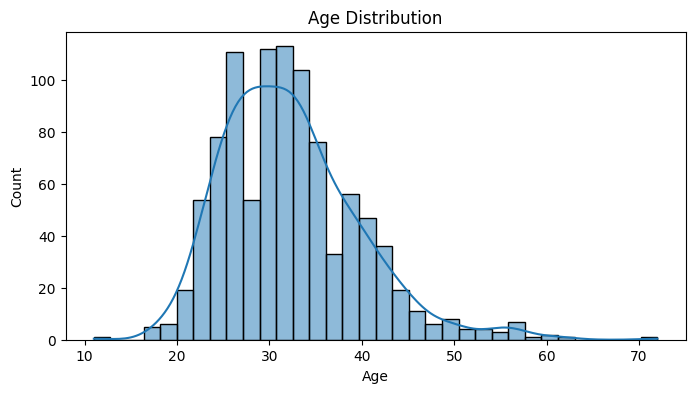

In [19]:
# Finding distribution of Age

plt.figure(figsize=(8, 4))
sns.histplot(data = df , x= 'Age', kde=True)
plt.xlabel('Age')
plt.title('Age Distribution')
plt.show()

In [20]:
# Distribution of Treatment

df['treatment'].value_counts().reset_index(name='count')

,treatment,count
0,Yes,619
1,No,353


After data wrangling and data processing, the treatment column appears to be slighly skewed to "Yes"

In [21]:
# Encoding Categorical values to make them Boolean

df = pd.get_dummies(df, drop_first=True)
display(df.head(10))

,Age,Gender_Male,Gender_Other,self_employed_Yes,family_history_Yes,treatment_Yes,work_interfere_Often,work_interfere_Rarely,work_interfere_Sometimes,no_employees_100-500,...,coworkers_Yes,supervisor_Some of them,supervisor_Yes,mental_health_interview_No,mental_health_interview_Yes,phys_health_interview_No,phys_health_interview_Yes,mental_vs_physical_No,mental_vs_physical_Yes,obs_consequence_Yes
18,46,True,False,True,True,False,False,False,True,False,...,True,False,True,True,False,False,True,False,True,True
20,29,True,False,False,True,True,False,False,True,True,...,False,True,False,True,False,True,False,True,False,False
21,31,True,False,True,False,False,False,False,False,False,...,False,True,False,True,False,False,False,False,True,False
22,46,True,False,False,False,True,True,False,False,False,...,False,False,True,True,False,False,False,True,False,False
23,41,True,False,False,False,True,False,False,False,False,...,False,False,False,True,False,False,True,False,False,False
24,33,True,False,False,True,True,False,True,False,False,...,True,False,True,True,False,False,True,False,False,False
25,35,True,False,False,True,True,False,False,True,False,...,False,False,True,True,False,False,True,True,False,False
27,35,True,False,False,True,True,False,True,False,False,...,True,False,True,False,False,False,False,False,True,False
28,34,True,False,False,False,True,False,False,True,False,...,False,False,False,True,False,True,False,True,False,False
29,37,True,False,False,False,False,False,False,True,False,...,False,False,False,True,False,False,False,True,False,False


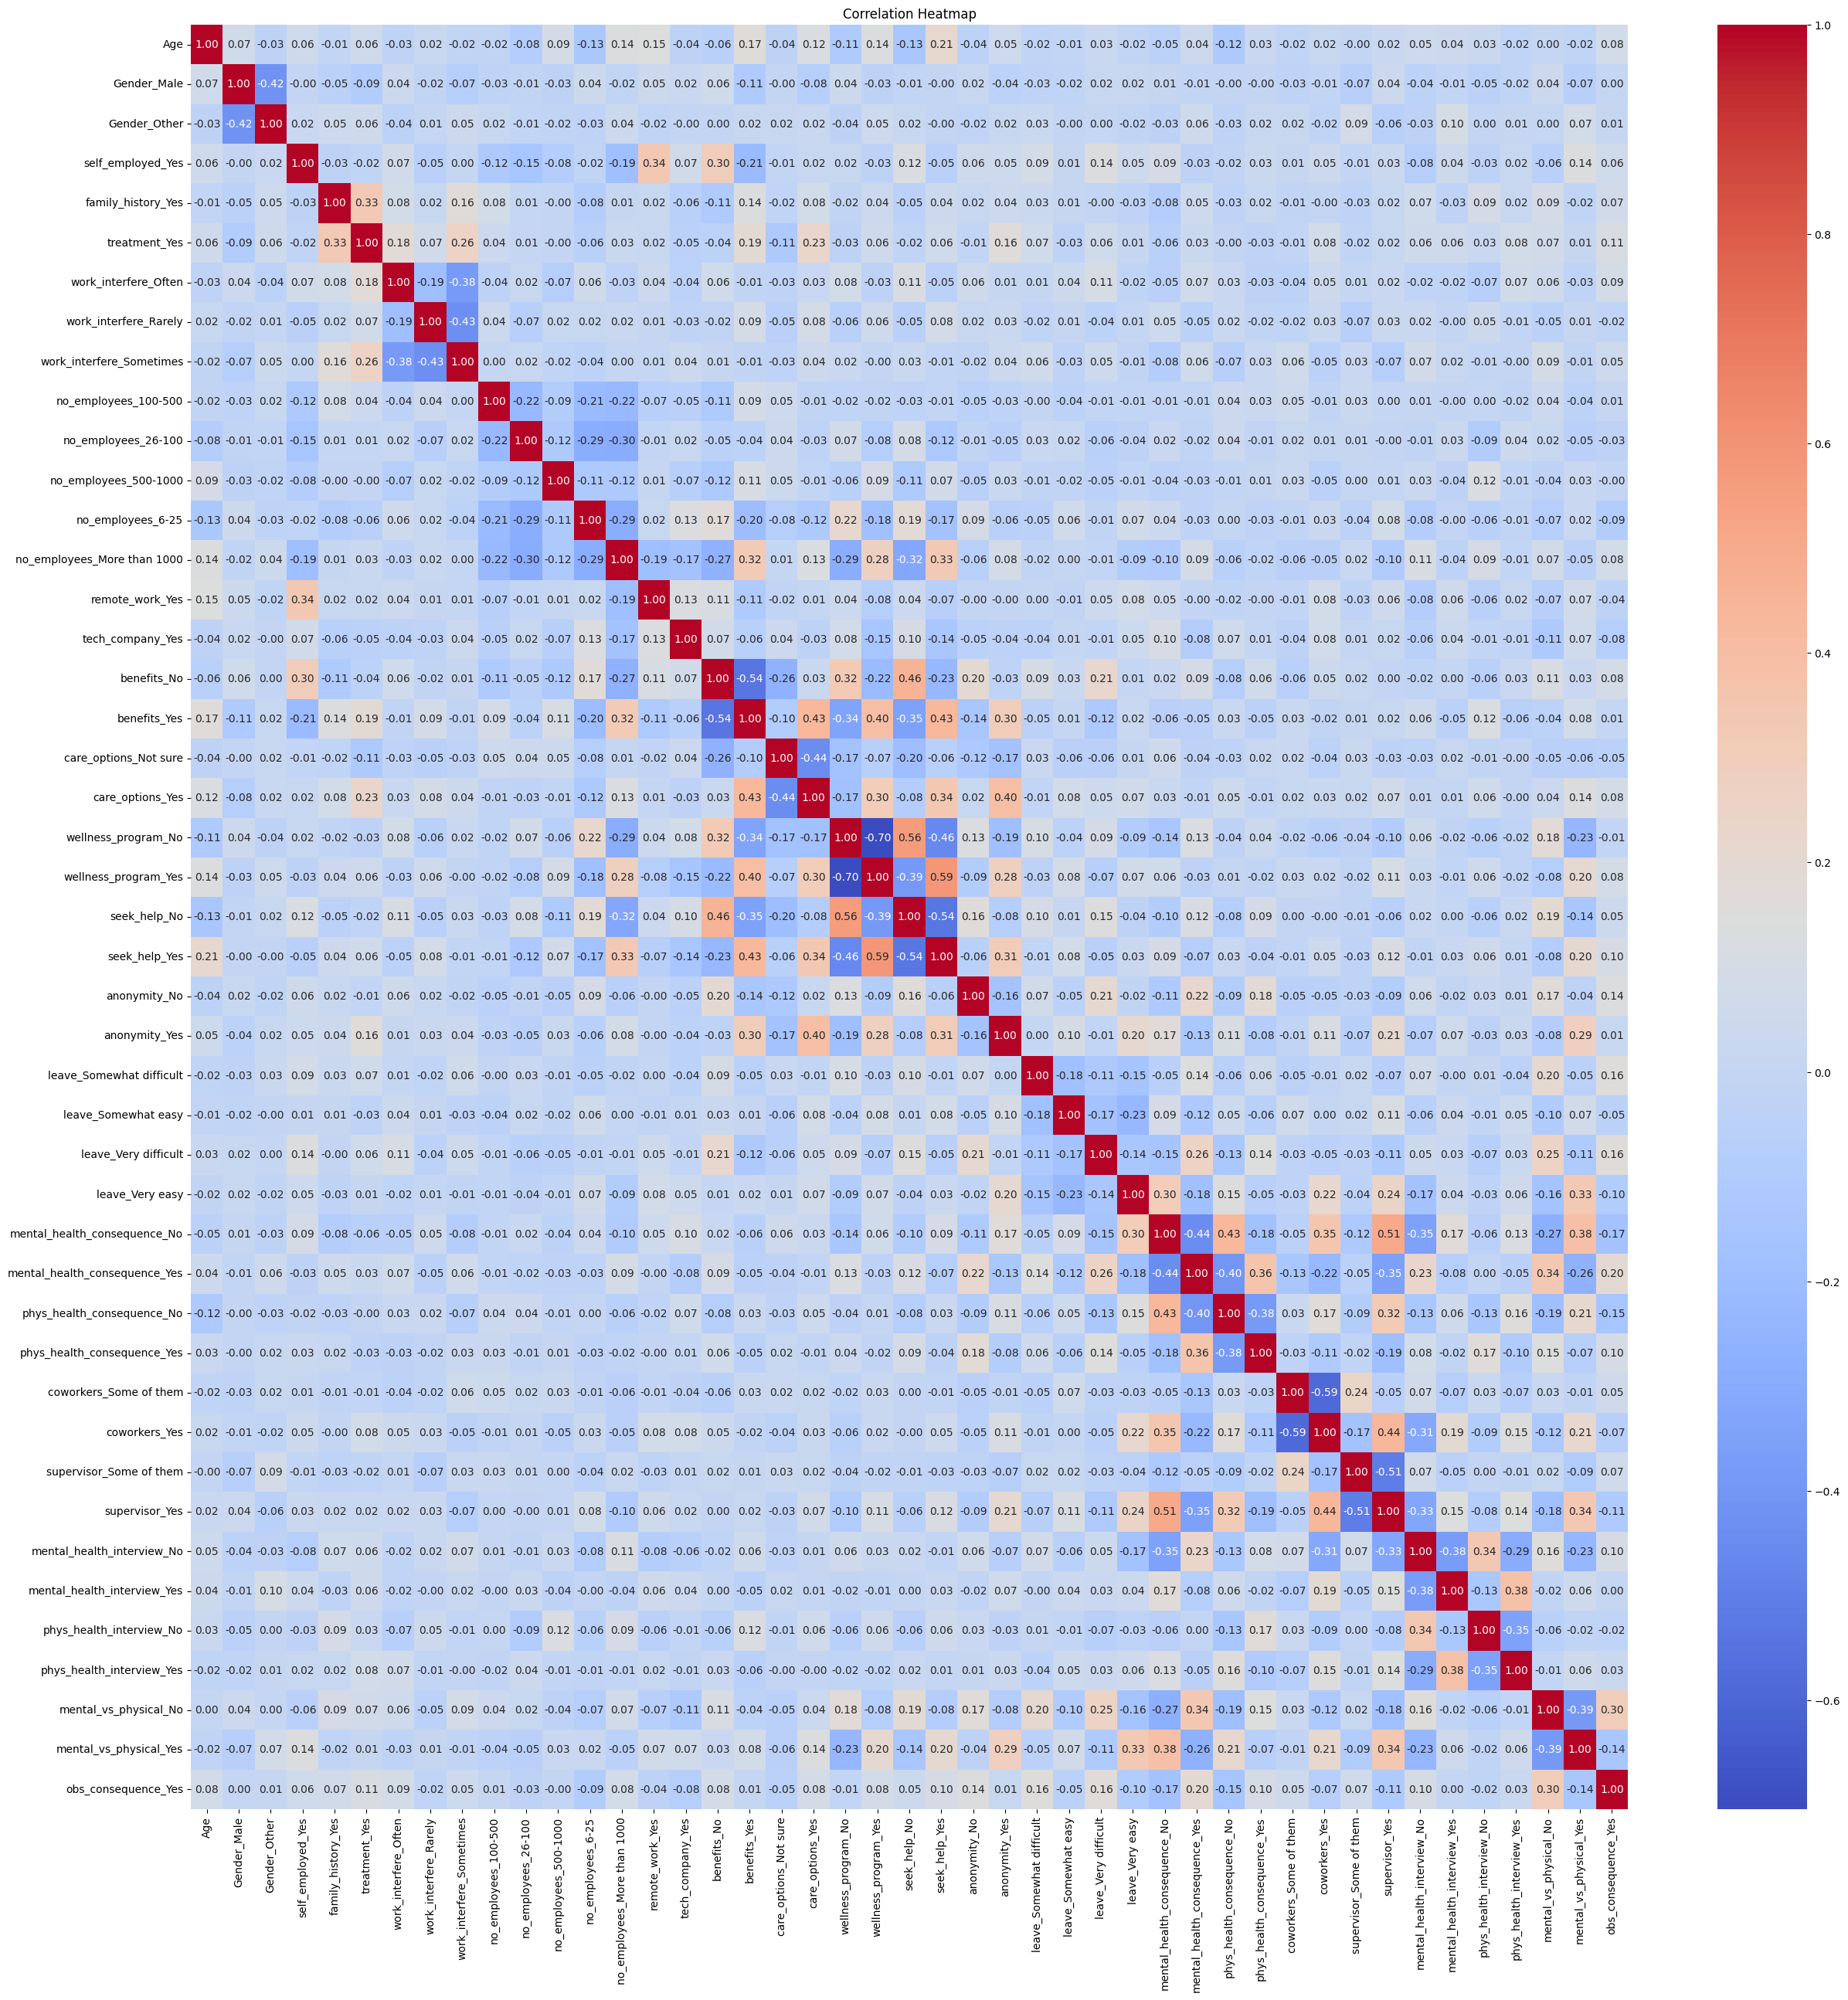

In [22]:
# Correlation Heatmap to check for multocolinearity

corr = df.corr()

plt.figure(figsize=(30, 30))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

There appears to be little or no multicollinearity, as the independent variables do not exhibit strong correlations with one another.

### **Result of EDA**

The exploratory data analysis revealed bias in target variable category representation, low multicollinearity among independent variables, and relatively uneven data distribution patterns.

## **Predictive Analysis**

### Identifying The Most Important Features

Since the classifier models produced relatively low accuracy scores while initially carrying out the predictive analysis, even after adjusting the train-test split distribution, feature selection will be performed to reduce the number of independent variables and identify the most important predictors contributing to the target variable. This can help improve model performance, reduce noise, minimize overfitting, and enhance interpretability.

In [23]:
# Using correlation with target variable

corr['treatment_Yes'].sort_values(ascending=False)

,treatment_Yes
treatment_Yes,1.000000
family_history_Yes,0.328555
work_interfere_Sometimes,0.257035
care_options_Yes,0.229552
benefits_Yes,0.190764
work_interfere_Often,0.178469
anonymity_Yes,0.161899
obs_consequence_Yes,0.108109
phys_health_interview_Yes,0.079798
coworkers_Yes,0.075499


### Train/Test Split

In [24]:
df['treatment'] = df['treatment_Yes']

In [25]:
# Train Test Split

X = df.drop(['treatment', 'treatment_Yes'], axis=1)
y = df['treatment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
x_train, x_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)
display(X.head())
display(y.head())

,Age,Gender_Male,Gender_Other,self_employed_Yes,family_history_Yes,work_interfere_Often,work_interfere_Rarely,work_interfere_Sometimes,no_employees_100-500,no_employees_26-100,...,coworkers_Yes,supervisor_Some of them,supervisor_Yes,mental_health_interview_No,mental_health_interview_Yes,phys_health_interview_No,phys_health_interview_Yes,mental_vs_physical_No,mental_vs_physical_Yes,obs_consequence_Yes
18,46,True,False,True,True,False,False,True,False,False,...,True,False,True,True,False,False,True,False,True,True
20,29,True,False,False,True,False,False,True,True,False,...,False,True,False,True,False,True,False,True,False,False
21,31,True,False,True,False,False,False,False,False,False,...,False,True,False,True,False,False,False,False,True,False
22,46,True,False,False,False,True,False,False,False,True,...,False,False,True,True,False,False,False,True,False,False
23,41,True,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,True,False,False,False


,treatment
18,False
20,True
21,False
22,True
23,True


In [26]:
# Balancing the distribution of the target variable

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [27]:
# Using random forest classifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X, y)

importance = pd.Series(rf.feature_importances_,
                       index=X.columns)

importance.sort_values(ascending=False)

,0
Age,0.104139
family_history_Yes,0.077583
work_interfere_Sometimes,0.068558
work_interfere_Often,0.043494
care_options_Yes,0.035666
work_interfere_Rarely,0.034043
benefits_Yes,0.025899
remote_work_Yes,0.025033
anonymity_Yes,0.024925
phys_health_interview_No,0.024019


In [28]:
# Limiting the independent variables to the top 10 features from the random forest feature seelection

top_features = importance.nlargest(10).index

X_train = X_train[top_features]
X_test = X_test[top_features]

display(X_train.head())
display(X_test.head())

,Age,family_history_Yes,work_interfere_Sometimes,work_interfere_Often,care_options_Yes,work_interfere_Rarely,benefits_Yes,remote_work_Yes,anonymity_Yes,phys_health_interview_No
0,35,False,True,False,False,False,False,False,False,False
1,26,False,True,False,False,False,False,True,True,False
2,43,True,True,False,False,False,True,True,False,False
3,30,False,True,False,False,False,False,True,False,False
4,32,True,True,False,False,False,False,False,False,True


,Age,family_history_Yes,work_interfere_Sometimes,work_interfere_Often,care_options_Yes,work_interfere_Rarely,benefits_Yes,remote_work_Yes,anonymity_Yes,phys_health_interview_No
1019,25,False,False,False,False,True,False,True,False,False
110,22,False,True,False,True,False,True,False,True,False
1119,34,False,False,False,True,False,False,True,False,True
633,34,False,True,False,True,False,True,True,False,True
861,26,False,False,False,False,True,False,True,False,False


### Scaling the Independent Variables

In [29]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns) # Split for ML models
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns) # Split for DL model

display(X_train_scaled_df.head())
display(X_test_scaled_df.head())

,Age,family_history_Yes,work_interfere_Sometimes,work_interfere_Often,care_options_Yes,work_interfere_Rarely,benefits_Yes,remote_work_Yes,anonymity_Yes,phys_health_interview_No
0,0.397700,-0.771667,1.20783,-0.361571,-0.701198,-0.406798,-0.715730,-0.609384,-0.603127,-0.725476
1,-0.808036,-0.771667,1.20783,-0.361571,-0.701198,-0.406798,-0.715730,1.641001,1.658026,-0.725476
2,1.469466,1.295897,1.20783,-0.361571,-0.701198,-0.406798,1.397174,1.641001,-0.603127,-0.725476
3,-0.272153,-0.771667,1.20783,-0.361571,-0.701198,-0.406798,-0.715730,1.641001,-0.603127,-0.725476
4,-0.004212,1.295897,1.20783,-0.361571,-0.701198,-0.406798,-0.715730,-0.609384,-0.603127,1.378405


,Age,family_history_Yes,work_interfere_Sometimes,work_interfere_Often,care_options_Yes,work_interfere_Rarely,benefits_Yes,remote_work_Yes,anonymity_Yes,phys_health_interview_No
0,-0.942007,-0.771667,-0.827931,-0.361571,-0.701198,2.458222,-0.715730,1.641001,-0.603127,-0.725476
1,-1.343919,-0.771667,1.207830,-0.361571,1.426130,-0.406798,1.397174,-0.609384,1.658026,-0.725476
2,0.263729,-0.771667,-0.827931,-0.361571,1.426130,-0.406798,-0.715730,1.641001,-0.603127,1.378405
3,0.263729,-0.771667,1.207830,-0.361571,1.426130,-0.406798,1.397174,1.641001,-0.603127,1.378405
4,-0.808036,-0.771667,-0.827931,-0.361571,-0.701198,2.458222,-0.715730,1.641001,-0.603127,-0.725476


### Predicting Using Machine Learning Models

In [30]:
classifier ={
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
   "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
}

for name, clf in classifier.items():
    print(f"\n============{name}============")
    clf.fit(X_train, y_train)
    y_pred =clf.predict(X_test)
    print(f'\n Accuracy: {accuracy_score(y_test,y_pred)}')
    print(f'\n Fi Score: {f1_score(y_test,y_pred)}')
    print(f'\n Precision: {precision_score(y_test,y_pred)}')
    print(f'\n Recall: {recall_score(y_test,y_pred)}')
    print(f'\n Confussion matrix:\n{confusion_matrix(y_test,y_pred)}')



============Logistic Regression============

 Accuracy: 0.8

 Fi Score: 0.8433734939759037

 Precision: 0.8536585365853658

 Recall: 0.8333333333333334

 Confussion matrix:
[[ 51  18]
 [ 21 105]]

============Decision Tree============

 Accuracy: 0.6666666666666666

 Fi Score: 0.7325102880658436

 Precision: 0.7606837606837606

 Recall: 0.7063492063492064

 Confussion matrix:
[[41 28]
 [37 89]]

============Random Forest============

 Accuracy: 0.7230769230769231

 Fi Score: 0.784

 Precision: 0.7903225806451613

 Recall: 0.7777777777777778

 Confussion matrix:
[[43 26]
 [28 98]]

============Gradient Boosting============

 Accuracy: 0.8

 Fi Score: 0.8421052631578947

 Precision: 0.859504132231405

 Recall: 0.8253968253968254

 Confussion matrix:
[[ 52  17]
 [ 22 104]]


In [31]:
results = []

classifier = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
}

for name, clf in classifier.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,F1 Score,Precision,Recall
0,Logistic Regression,0.800000,0.843373,0.853659,0.833333
1,Decision Tree,0.682051,0.743802,0.775862,0.714286
2,Random Forest,0.738462,0.796813,0.800000,0.793651
3,Gradient Boosting,0.800000,0.842105,0.859504,0.825397


<Figure size 500x500 with 0 Axes>

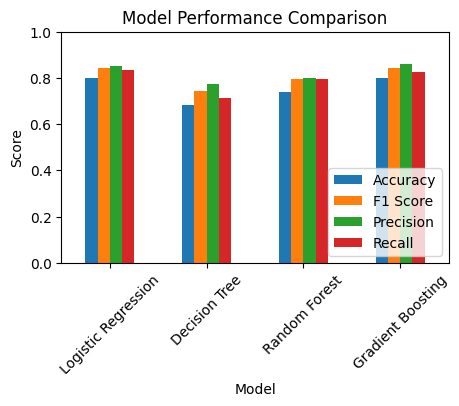

In [32]:
# Visualizing The Model Performance

plt.figure(figsize=(5, 5))

results_df.set_index("Model").plot(
    kind="bar",
    figsize=(5, 3)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.show()

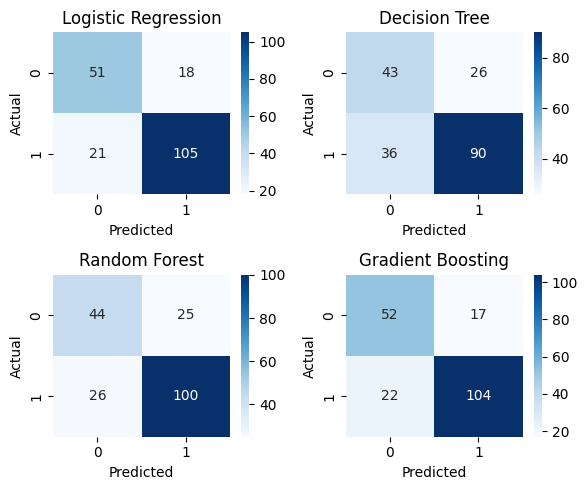

In [33]:
# Visualizing Confusuin Matrix

fig, axes = plt.subplots(2, 2, figsize=(6, 5))
axes = axes.flatten()

for ax, (name, clf) in zip(axes, classifier.items()):
    y_pred = clf.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## Prediction Using Deep Learning

In [34]:
# Building the model

model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    # tf.keras.layers.Dropout(0.2), # Adding dropout to prevent overfitting
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
# Configuring the Model learniing

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [36]:
# trained model
print(model)

<Sequential name=sequential, built=True>


In [37]:
# Early Stopping to prevent overfitting

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 10,
    restore_best_weights = True
)

In [38]:
# Training the model

X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

y_train = y_train.astype('float32')
y_test = y_test.astype('float32')

print('\nTraining the AI model...')
history = model.fit(X_train, y_train,
                   epochs = 500,
                   verbose = 1,
                   validation_split = 0.2,
                   callbacks = [early_stopping])


Training the AI model...
Epoch 1/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6269 - loss: 0.6685 - val_accuracy: 0.0000e+00 - val_loss: 0.7541
Epoch 2/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6421 - loss: 0.6299 - val_accuracy: 0.0000e+00 - val_loss: 0.9147
Epoch 3/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6548 - loss: 0.6014 - val_accuracy: 0.5758 - val_loss: 0.7154
Epoch 4/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7119 - loss: 0.5768 - val_accuracy: 0.8636 - val_loss: 0.5143
Epoch 5/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7348 - loss: 0.5632 - val_accuracy: 0.5707 - val_loss: 0.8301
Epoch 6/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7310 - loss: 0.5504 - val_accuracy: 0.8434 - val_loss: 0.5125
Epoch 7/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7360 - loss: 0.5411 - val_accuracy: 0.6869 - val_loss: 0.6410
Epoch 8/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7234 - 

In [39]:
y_pred_prob = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [40]:
y_pred = (y_pred_prob > 0.5).astype(int)

In [41]:
ANN_results = []

ANN_results.append({
    "Model": "ANN",
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred)
})

ANN_results_df = pd.DataFrame(ANN_results)

display(ANN_results_df)

,Model,Accuracy,F1 Score,Precision,Recall
0,ANN,0.676923,0.709677,0.846154,0.611111


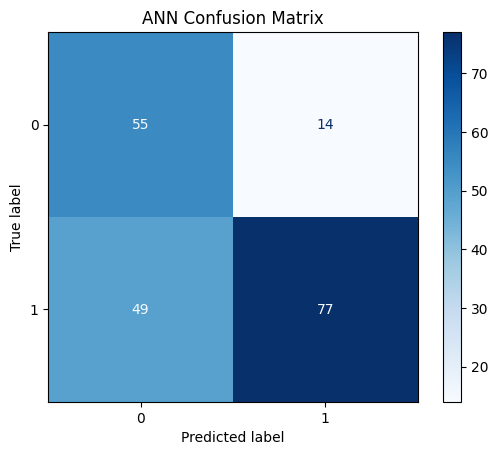

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("ANN Confusion Matrix")
plt.show()